# dependencies: papermill and scrapbook

In [1]:
!ls
!pip install scrapbook
!pip install papermill
!pip install adjustText

Ag_Plot_Test_Protocol-2.ipynb	 ag14100  ag14347		  r14235.ipynb
Ag_Plot_Test_Protocol-3.ipynb	 ag14106  ag14370		  r14268.ipynb
Ag_Plot_Test_Protocol.ipynb	 ag14112  ag14382		  r14286.ipynb
Preliminary_Scurve_2025.ipynb	 ag14235  comparison_s_curve.png  r14308.ipynb
README.txt			 ag14268  data_onlyramp.txt	  r14314.ipynb
S_curve.png			 ag14286  data_onlywait.txt	  r14318.ipynb
Utils.py			 ag14308  figures		  r14332.ipynb
Zpdf_comparison.png		 ag14314  old_Ag_Plot.ipynb	  r14338.ipynb
Zpdf_comparison.zip		 ag14318  old_script.ipynb	  r14342.ipynb
Zpds_three_segments_ag14100.tar  ag14332  r14100.ipynb		  r14347.ipynb
__pycache__			 ag14338  r14106.ipynb		  r14370.ipynb
ag13628				 ag14342  r14112.ipynb		  r14382.ipynb
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import papermill as pm
import scrapbook as sb
import numpy as np
from matplotlib import pyplot as plt
from adjustText import adjust_text
import pandas as pd

In [3]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


# Get Chuckman Simulation

In [4]:
df = pd.read_excel("../chuckman_simulation/vertices_counts_v5.xlsx")



#print(df.head())
#print(df["1st release ramp segment"])
#print(df["Unnamed: 10"])
#print(df["Unnamed: 2"])

df = df.rename(columns={'Unnamed: 2'         : 'bias',
                   'Unnamed: 0'              : 'Oc current',
                   'Unnamed: 1'              : 'ramp duration',
                   '1st release ramp segment': 'bottom seg.1',
                   'Unnamed: 10'             : 'top seg.1',
                   '2nd release ramp segment': 'bottom seg.2',
                   'Unnamed: 16'             : 'top seg.2' })

print(df.columns.tolist())

typeSimulation = np.array(df['Oc current'][1:].tolist())
biases_sim = np.array(df['bias'][1:])
duration = np.array(df['ramp duration'][1:])

print(typeSimulation, biases_sim, duration)

segment1_up   = df['top seg.1'][1:].tolist()
segment1_down = df['bottom seg.1'][1:].tolist()

segment2_up   = df['top seg.2'][1:].tolist()
segment2_down = df['bottom seg.2'][1:].tolist()

print(segment1_up, segment1_down)
print("-"*50)
print(segment2_up, segment2_down)

# segment7_up   = df['Window 7 up'].tolist()
# segment7_down = df['Window 7 down'].tolist()

# TotUp   =  np.array(segment7_up) + np.array(segment6_up)
# TotDown =  np.array(segment7_down) + np.array(segment6_down)
# simulation    = TotDown / (TotUp + TotDown)

TotUp   =  np.array(segment1_up)
TotDown =  np.array(segment1_down)
simulation_s1 = (TotDown - TotUp) / (TotUp + TotDown)

TotUp   =  np.array(segment2_up)
TotDown =  np.array(segment2_down)
simulation_s2 = (TotDown - TotUp) / (TotUp + TotDown)

mask = (typeSimulation == 220) & (duration ==  10)

simulation_s1 = simulation_s1[mask]
simulation_s2 = simulation_s2[mask]
biases_sim = biases_sim[mask]
print(simulation_s1)

# print(mask)

# simulation_830 = simulation[mask]
# simulation_s6_830 = simulation_s6[mask]
# simulation_s7_830 = simulation_s7[mask]
# biases_sim_830 = biases_sim[mask]

# mask = (typeSimulation == 275) & (duration == 10)

# simulation_275 = simulation[mask]
# simulation_s6_275 = simulation_s6[mask]
# simulation_s7_275 = simulation_s7[mask]
# biases_sim_275 = biases_sim[mask]

# print(biases_sim_275, simulation_275)



['Oc current', 'ramp duration', 'bias', 'Unnamed: 3', 'Unnamed: 4', 'Hold', 'Unnamed: 6', 'Unnamed: 7', 'bottom seg.1', 'Unnamed: 9', 'top seg.1', 'Hold.1', 'Unnamed: 12', 'Unnamed: 13', 'bottom seg.2', 'Unnamed: 15', 'top seg.2', 'Hold.2', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']
[220 220 220 220 220 220 220 220 220 220 220 220 220 220 220 220 830 830
 830 830 830 830 830 830 830 830 830 830 830 830 830 830] [-0.04 -0.02 0 0.02 0.04 0.06 0.08 0.1 -0.04 -0.02 0 0.02 0.04 0.06 0.08
 0.1 -0.04 -0.02 0 0.02 0.04 0.06 0.08 0.1 -0.04 -0.02 0 0.02 0.04 0.06
 0.08 0.1] [10 10 10 10 10 10 10 10 100 100 100 100 100 100 100 100 10 10 10 10 10 10
 10 10 100 100 100 100 100 100 100 100]
[1134, 1101, 1095, 1066, 941, 929, 897, 876, 1797, 1784, 1702, 1629, 1478, 1404, 1212, 1074, 2479, 2231, 2024, 1461, 1202, 899, 744, 599, 3310, 2706, 2949, 1753, 1101, 831, 711, 440] [637, 703, 794, 876, 999, 1102, 1236, 1282, 1103, 1166, 1271, 1430, 1538, 1621, 1609, 1595, 749, 1089, 1473, 1759, 2113, 2486, 28

# Dictionary to link the run at the nominal bias
# Modify this by adding manually the runs

In [5]:
# add entry here ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
dictRun = {
           "ag14106/ag14106.vertex.csv": -2,
           "ag14342/ag14342.vertex.csv": -1.25, # 4 segments long ramp
           "ag14268/ag14268.vertex.csv": -1.25,
           "ag14347/ag14347.vertex.csv": -1.125,
           "ag14286/ag14286.vertex.csv": -1,
           "ag14332/ag14332.vertex.csv": -1,    #  4 segments "long ramp"
           "ag14382/ag14382.vertex.csv": -1,
           "ag14338/ag14338.vertex.csv": -.875, #  4 segments "long ramp"
           "ag14370/ag14370.vertex.csv": -.875, #  single release segment
           "ag14112/ag14112.vertex.csv": -.75,
           "ag14314/ag14314.vertex.csv": -.75, #  4 segments
           "ag14318/ag14318.vertex.csv": -.74, #  4 segments with longer ramp and waits,
           "ag14308/ag14308.vertex.csv": -.5,  
           "ag14100/ag14100.vertex.csv": 0,
          }

# Dictionary which specifies the type of release [short, long, single] and number of segments [3seg, 4seg, 1seg]
dictRamp = {
           "ag14106/ag14106.vertex.csv": ["short", "3seg"],
           "ag14342/ag14342.vertex.csv": ["long",  "4seg"],
           "ag14268/ag14268.vertex.csv": ["short", "3seg"],
           "ag14286/ag14286.vertex.csv": ["short", "3seg"],
           "ag14347/ag14347.vertex.csv": ["long",  "4seg"],
           "ag14332/ag14332.vertex.csv": ["long",  "4seg"],
           "ag14382/ag14382.vertex.csv": ["single","1seg"],
           "ag14338/ag14338.vertex.csv": ["long",  "4seg"],
           "ag14370/ag14370.vertex.csv": ["single","1seg"], #  single release segment
           "ag14112/ag14112.vertex.csv": ["short", "3seg"],
           "ag14314/ag14314.vertex.csv": ["short", "4seg"],
           "ag14318/ag14318.vertex.csv": ["long",  "4seg"],
           "ag14308/ag14308.vertex.csv": ["short", "3seg"],
           "ag14100/ag14100.vertex.csv": ["short", "3seg"]
          }


'Ag_Plot_Test_Protocol.ipynb' # => first protocol with 3 segments
'Ag_Plot_Test_Protocol-2.ipynb' # => second protocol with 4 segments

ListScript = {
           "ag14106/ag14106.vertex.csv": 'Ag_Plot_Test_Protocol.ipynb',
           "ag14342/ag14342.vertex.csv": "Ag_Plot_Test_Protocol-2.ipynb", #  4 segments "long ramp"
           "ag14268/ag14268.vertex.csv": 'Ag_Plot_Test_Protocol.ipynb',
           "ag14286/ag14286.vertex.csv": 'Ag_Plot_Test_Protocol.ipynb',
           "ag14347/ag14347.vertex.csv": "Ag_Plot_Test_Protocol-2.ipynb", #  4 segments "long ramp"
           "ag14332/ag14332.vertex.csv": "Ag_Plot_Test_Protocol-2.ipynb", #  4 segments "long ramp"
           "ag14382/ag14382.vertex.csv": 'Ag_Plot_Test_Protocol-3.ipynb', #  single release segment
           "ag14338/ag14338.vertex.csv": "Ag_Plot_Test_Protocol-2.ipynb", #  4 segments "long ramp"
           "ag14370/ag14370.vertex.csv": 'Ag_Plot_Test_Protocol-3.ipynb', #  single release segment
           "ag14112/ag14112.vertex.csv": 'Ag_Plot_Test_Protocol.ipynb',
           "ag14314/ag14314.vertex.csv": 'Ag_Plot_Test_Protocol-2.ipynb', #  4 segments
           "ag14318/ag14318.vertex.csv": 'Ag_Plot_Test_Protocol-2.ipynb', #  4 segments "long ramp"
           "ag14308/ag14308.vertex.csv": 'Ag_Plot_Test_Protocol.ipynb',
           "ag14100/ag14100.vertex.csv": 'Ag_Plot_Test_Protocol.ipynb',
}

# Extract Preliminary S-curve

In [22]:
# Standard ramps
S_ramp1,  S_ramp2,  S_ramp3,  S_ramp4  = [],[],[],[]
dS_ramp1, dS_ramp2, dS_ramp3, dS_ramp4 = [],[],[],[]

# Standard ramps + wait time
S_ramp1_wait,  S_ramp2_wait,  S_ramp3_wait,  S_ramp4_wait     = [],[],[],[]
dS_ramp1_wait, dS_ramp2_wait, dS_ramp3_wait, dS_ramp4_wait    = [],[],[],[]

# Only wait time between ramps
S_ramp1_onlywait,  S_ramp2_onlywait,  S_ramp3_onlywait,  S_ramp4_onlywait     = [],[],[],[]
dS_ramp1_onlywait, dS_ramp2_onlywait, dS_ramp3_onlywait, dS_ramp4_onlywait    = [],[],[],[]

# Standard ramps, boil-off
S_boiloff,  S_boiloff_first,  S_boiloff_second  = [], [], []
dS_boiloff, dS_boiloff_first, dS_boiloff_second = [], [], []
S_boiloff2  = []
dS_boiloff2 = []

# Single release to 0.7 mT protocol
S_rampsingle, dS_rampsingle = [], []
S_rampsingle_wait, dS_rampsingle_wait = [], []

# list of bias for run with three segment, four segment and only one segment
bias = []
list_runs = []


Ntot_list, Nup_list, Ndown_list = [],[],[]

In [7]:
############################
# MAIN ANALYSIS LOOP
###########################
for key, bias_ in dictRun.items():
    print(key, ListScript[key] )
    pm.execute_notebook(
        ListScript[key],
        f'{key.split("/")[0].replace("ag","r")}.ipynb',
        parameters= {"run_to_analyze" : key}
    )

ag14106/ag14106.vertex.csv Ag_Plot_Test_Protocol.ipynb


Executing:   0%|          | 0/32 [00:00<?, ?cell/s]

ag14342/ag14342.vertex.csv Ag_Plot_Test_Protocol-2.ipynb


Executing:   0%|          | 0/31 [00:00<?, ?cell/s]

ag14268/ag14268.vertex.csv Ag_Plot_Test_Protocol.ipynb


...

Executing:   0%|          | 0/31 [00:00<?, ?cell/s]

ag14308/ag14308.vertex.csv Ag_Plot_Test_Protocol.ipynb


Executing:   0%|          | 0/32 [00:00<?, ?cell/s]

ag14100/ag14100.vertex.csv Ag_Plot_Test_Protocol.ipynb


Executing:   0%|          | 0/32 [00:00<?, ?cell/s]

In [23]:
def tryScraps(nb,label):
    "Function that read the notebook and search for variables"
    Sextr, dSextr = 0,0
    booleano = True
    try:
        Sextr, dSextr = nb.scraps[label].data[0], nb.scraps[label].data[1]
        booleano = True # true if the variables are found in the notebook
    except:
        print(f"no {label} found")
        Sextr, dSextr = np.nan, np.nan
    return Sextr, dSextr, booleano


type_ramp  = [] # short, long
type_exp   = [] # number of segments
for key, bias_ in dictRun.items():
    print(key)
    
    # read result
    nb = sb.read_notebook(f'{key.split("/")[0].replace("ag","r")}.ipynb')
    
    Sextr, dSextr, flag = tryScraps(nb, "ramp_single")
    if(flag): S_rampsingle.append(Sextr); dS_rampsingle.append(dSextr)
    
    Sextr, dSextr, flag = tryScraps(nb, "ramp_single_wait")
    if(flag): S_rampsingle_wait.append(Sextr); dS_rampsingle_wait.append(dSextr)
    
    ############################
    ### Three Ramps Segments
    ############################
    Sextr, dSextr, flag = tryScraps(nb, "ramp1") 
    if(flag): S_ramp1.append(Sextr); dS_ramp1.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp2") 
    if(flag): S_ramp2.append(Sextr); dS_ramp2.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp3") 
    if(flag): S_ramp3.append(Sextr); dS_ramp3.append(dSextr)
    
    ############################
    ### Three ramps + wait time
    ############################
    Sextr, dSextr, flag = tryScraps(nb, "ramp1pluswait") 
    if(flag): S_ramp1_wait.append(Sextr); dS_ramp1_wait.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp2pluswait") 
    if(flag): S_ramp2_wait.append(Sextr); dS_ramp2_wait.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp3pluswait") 
    if(flag): S_ramp3_wait.append(Sextr); dS_ramp3_wait.append(dSextr)

    #############################
    ### Three ramps only wait time
    #############################
    Sextr, dSextr, flag = tryScraps(nb, "ramp1onlywait")
    if(flag): S_ramp1_onlywait.append(Sextr); dS_ramp1_onlywait.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp2onlywait")
    if(flag): S_ramp2_onlywait.append(Sextr); dS_ramp2_onlywait.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp3onlywait")
    if(flag): S_ramp3_onlywait.append(Sextr); dS_ramp3_onlywait.append(dSextr)

    ############################
    # Analysis on Boiloff events
    ############################
    Sextr, dSextr, flag = tryScraps(nb, "boiloff")
    if(flag): S_boiloff.append(Sextr); dS_boiloff.append(dSextr)
    
    Sextr, dSextr, flag = tryScraps(nb, "boiloff_firstpart")
    if(flag): S_boiloff_first.append(Sextr); dS_boiloff_first.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "boiloff_lastpart")
    if(flag): S_boiloff_second.append(Sextr); dS_boiloff_second.append(dSextr)

    #############################
    ### 4th only wait time
    #############################

    Sextr, dSextr, flag = tryScraps(nb, "ramp4")
    if(flag): S_ramp4.append(Sextr); dS_ramp4.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "ramp4onlywait")
    if(flag): S_ramp4_onlywait.append(Sextr); dS_ramp4_onlywait.append(dSextr)

    Sextr, dSextr, flag = tryScraps(nb, "boiloff_2")
    if(flag): S_boiloff2.append(Sextr); dS_boiloff2.append(dSextr)

    ##################################
    # APPEND BIAS AND MASK
    bias.append(bias_)
    list_runs.append(key.split("/")[0].replace("ag","r"))
    
    type_ramp.append(dictRamp[key][0]) # get and set type of ramp
    type_exp.append(dictRamp[key][1])  # get and set type of experiment

ag14106/ag14106.vertex.csv
no ramp_single found
no ramp_single_wait found
no ramp4 found
no ramp4onlywait found
no boiloff_2 found
ag14342/ag14342.vertex.csv
no ramp_single found
no ramp_single_wait found
ag14268/ag14268.vertex.csv
no ramp_single found
no ramp_single_wait found
no ramp4 found
no ramp4onlywait found
no boiloff_2 found
ag14347/ag14347.vertex.csv
no ramp_single found
no ramp_single_wait found
ag14286/ag14286.vertex.csv
no ramp_single found
no ramp_single_wait found
no ramp4 found
no ramp4onlywait found
no boiloff_2 found
ag14332/ag14332.vertex.csv
no ramp_single found
no ramp_single_wait found
ag14382/ag14382.vertex.csv
no ramp1 found
no ramp2 found
no ramp3 found
no ramp1pluswait found
no ramp2pluswait found
no ramp3pluswait found
no ramp1onlywait found
no ramp2onlywait found
no ramp3onlywait found
no boiloff found
no boiloff_firstpart found
no boiloff_lastpart found
no ramp4 found
no ramp4onlywait found
no boiloff_2 found
ag14338/ag14338.vertex.csv
no ramp_single found


# Convert python list in numpy array to work with mask

In [24]:
S_ramp1, S_ramp2, S_ramp3, S_ramp4      =  np.array(S_ramp1), np.array(S_ramp2), np.array(S_ramp3), np.array(S_ramp4, dtype=float)
dS_ramp1, dS_ramp2, dS_ramp3, dS_ramp4  =  np.array(dS_ramp1), np.array(dS_ramp2), np.array(dS_ramp3), np.array(dS_ramp4, dtype=float)

# convert bias and mask in np.array
bias = np.array(bias)
list_runs = np.array(list_runs)
type_ramp = np.array(type_ramp)
type_exp = np.array(type_exp)

S_ramp1_wait, S_ramp2_wait, S_ramp3_wait, S_ramp4_wait      = np.array(S_ramp1_wait), np.array(S_ramp2_wait), np.array(S_ramp3_wait), np.array(S_ramp4_wait, dtype=float)
dS_ramp1_wait, dS_ramp2_wait, dS_ramp3_wait, dS_ramp4_wait  = np.array(dS_ramp1_wait), np.array(dS_ramp2_wait), np.array(dS_ramp3_wait), np.array(dS_ramp4_wait, dtype=float)

S_rampsingle = np.array(S_rampsingle)
S_rampsingle_wait = np.array(S_rampsingle_wait)
dS_rampsingle = np.array(dS_rampsingle)
dS_rampsingle_wait = np.array(dS_rampsingle_wait)

S_ramp1_onlywait, S_ramp2_onlywait, S_ramp3_onlywait, S_ramp4_onlywait      = np.array(S_ramp1_onlywait), np.array(S_ramp2_onlywait), np.array(S_ramp3_onlywait), np.array(S_ramp4_onlywait, dtype=float)
dS_ramp1_onlywait, dS_ramp2_onlywait, dS_ramp3_onlywait, dS_ramp4_onlywait  = np.array(dS_ramp1_onlywait), np.array(dS_ramp2_onlywait), np.array(dS_ramp3_onlywait), np.array(dS_ramp4_onlywait, dtype=float)

In [25]:
from pprint import pprint
pprint(list_runs)
pprint(bias)
pprint(type_ramp)
pprint(type_exp)

print(2*"\n")

# List of runs available
print(f"| {'run number':<10} | {'bias':<8} | {'type ramp':<10} | {'n° ramps':<8} |")
for run_, bias_, type_ramp_, type_exp_ in zip(list_runs, bias, type_ramp, type_exp):
    print(f"| {run_:<10} | {bias_:<8} | {type_ramp_:<10} | {type_exp_:<8} |")

array(['r14106', 'r14342', 'r14268', 'r14347', 'r14286', 'r14332',
       'r14382', 'r14338', 'r14370', 'r14112', 'r14314', 'r14318',
       'r14308', 'r14100'], dtype='<U6')
array([-2.   , -1.25 , -1.25 , -1.125, -1.   , -1.   , -1.   , -0.875,
       -0.875, -0.75 , -0.75 , -0.74 , -0.5  ,  0.   ])
array(['short', 'long', 'short', 'long', 'short', 'long', 'single',
       'long', 'single', 'short', 'short', 'long', 'short', 'short'],
      dtype='<U6')
array(['3seg', '4seg', '3seg', '4seg', '3seg', '4seg', '1seg', '4seg',
       '1seg', '3seg', '4seg', '4seg', '3seg', '3seg'], dtype='<U4')



| run number | bias     | type ramp  | n° ramps |
| r14106     | -2.0     | short      | 3seg     |
| r14342     | -1.25    | long       | 4seg     |
| r14268     | -1.25    | short      | 3seg     |
| r14347     | -1.125   | long       | 4seg     |
| r14286     | -1.0     | short      | 3seg     |
| r14332     | -1.0     | long       | 4seg     |
| r14382     | -1.0     | single     | 1seg     

In [26]:
S_boiloff, dS_boiloff = np.array(S_boiloff), np.array(dS_boiloff)

S_ramp4_onlywait[S_ramp4_onlywait  > 1] = 1

In [27]:
# Make Plot Nicer
def plotter_nicer():
    plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
    plt.xlabel("bias", loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
    plt.ylim(-1.1,1.1)
    #plt.xlim(-3, 3)
    
    plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
    #plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
    plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
    plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")


def labelfactory(bias, S_ramp, listlist, labels, orientation = "right"):
    delta = 0
    if(orientation == "right"):
        delta += 44
    elif(orientation == "left"):
        delta += -84
    for xi, yi, txt in zip(bias, S_ramp, listlist):
        plt.annotate(
            txt,
            xy=(xi, yi),
            xytext=(delta, -15),          # distanza in pixel → aumenta per più distanza
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="black", linewidth = 1, alpha = 0.5),
            rotation=-15,
            fontsize = 8
        )

    plt.legend(fontsize=12)
    

# ->>> Preliminary Scurve, Segments

bias; S=Ndwn/(Ntot) ; dS


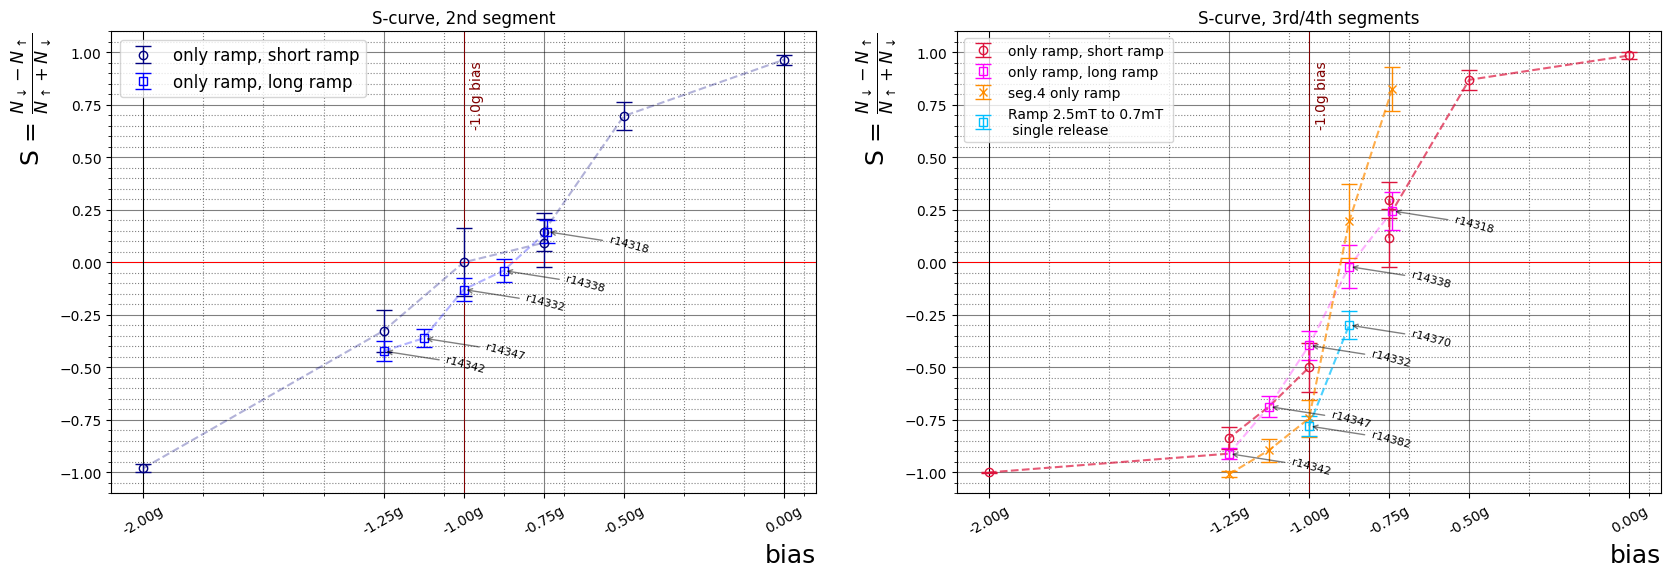

In [29]:
print("bias; S=Ndwn/(Ntot) ; dS")
labels = [-2, -1.25, -1, -.75, -0.5, 0]

plt.figure(1, figsize = (20, 6))

#--------------------------------------------------------------
plt.subplot(1,2,1)
plt.title("S-curve, 2nd segment")
plotter_nicer()

# plot short ramps
mask = (type_ramp == "short")
plt.errorbar(bias[mask], 
             S_ramp2[mask], 
             dS_ramp2[mask], marker = "o", markersize = 6, markerfacecolor='none', color = "navy", capsize = 6, elinewidth=1, linestyle = "", label = "only ramp, short ramp")
plt.errorbar(bias[mask], 
             S_ramp2[mask], 
             marker = "", color = "navy",  linestyle = "--", alpha = 0.3)
#labelfactory(bias[~type_ramp], S_ramp2[~type_ramp], list_runs[~type_ramp], labels, "left")

# plot long ramps -> type_ramp
mask = (type_ramp == "long")
plt.errorbar(bias[mask], 
             S_ramp2[mask], 
             dS_ramp2[mask], marker = "s", markersize = 6, markerfacecolor='none', color = "blue", capsize = 6, elinewidth=1, linestyle = "", label = "only ramp, long ramp")
plt.errorbar(bias[mask], 
             S_ramp2[mask], 
             marker = "", color = "blue",  linestyle = "--", alpha = 0.3)
labelfactory(bias[mask], 
             S_ramp2[mask], 
             list_runs[mask], labels, "right")

plt.xticks(labels, [f"{item:.2f}g" for item in labels], rotation=30)

# simulation
# plt.errorbar((biases_sim - 1), 
#              simulation_s1,
#              marker = ".", markersize = 6, markerfacecolor='none', color = "black", capsize = 6, linestyle = 'dotted', elinewidth=1, label = "simulation, first segment")

#plt.errorbar(bias, S_ramp2_onlywait, dS_ramp2_onlywait, marker = "*", markersize = 6, markerfacecolor='none', color = "blue", capsize = 6, elinewidth=1, linestyle = "",  label = "only wait")
#plt.errorbar(bias, S_ramp2_onlywait, marker = "", color = "blue",  linestyle = "--", alpha = 0.3)

#--------------------------------------------------------------
plt.subplot(1,2,2)
plt.title("S-curve, 3rd/4th segments")
plotter_nicer()

# 3rd segment
# plot short ramps
mask = (type_ramp == "short")

plt.errorbar(bias[mask],
             S_ramp3[mask], 
             dS_ramp3[mask], marker = "o", markersize = 6, markerfacecolor='none', color = "crimson", capsize = 6, linestyle = '', elinewidth=1, label = "only ramp, short ramp")
plt.errorbar(bias, S_ramp3, marker = "", color = "crimson", linestyle = "--", alpha = 0.7)
#labelfactory(bias, S_ramp3, list_runs, labels, "right")

# plot long ramps -> type_ramp
mask = (type_ramp == "long")

plt.errorbar(bias[mask],
             S_ramp3[mask], 
             dS_ramp3[mask], marker = "s", markersize = 6, markerfacecolor='none', color = "magenta", capsize = 6, linestyle = '', elinewidth=1, label = "only ramp, long ramp")
plt.errorbar(bias[mask], S_ramp3[mask], marker = "", color = "magenta", linestyle = "--", alpha = 0.3)
labelfactory(bias[mask], S_ramp3[mask], list_runs[mask], labels, "right")


# 4th segment
mask = (type_ramp == "long") & (type_exp == "4seg")

plt.errorbar(bias[mask], 
             S_ramp4[mask], 
             dS_ramp4[mask], marker = "x", markersize = 6, markerfacecolor='none', color = "darkorange", capsize = 6, linestyle = '', elinewidth=1, label = "seg.4 only ramp")

plt.errorbar(bias[mask], S_ramp4[mask], marker = "", color = "darkorange", linestyle = "--", alpha = 0.7)


mask = (type_ramp == "single")
plt.errorbar(bias[mask],
             S_rampsingle[mask], 
             dS_rampsingle[mask], marker = "s", markersize = 6, markerfacecolor='none', color = "deepskyblue", capsize = 6, linestyle = '', elinewidth=1, label = "Ramp 2.5mT to 0.7mT \n single release")
plt.errorbar(bias[mask], S_rampsingle[mask], marker = "", color = "deepskyblue", linestyle = "--", alpha = 0.7)
labelfactory(bias[mask], S_rampsingle[mask], list_runs[mask], labels, "right")


plt.legend()
plt.xticks(labels, [f"{item:.2f}g" for item in labels], rotation=30)

# simulation
# plt.errorbar((biases_sim - 1), 
#              simulation_s2,
#              marker = ".", markersize = 6, markerfacecolor='none', color = "black", capsize = 6, linestyle = 'dotted', elinewidth=1, label = "simulation, second segment")

plt.savefig("figures/S_curve_onlyramp.png", bbox_inches = 'tight')

# ->>> Preliminary S-curve, wait/bloiloff

bias; S=Ndwn/(Ntot) ; dS


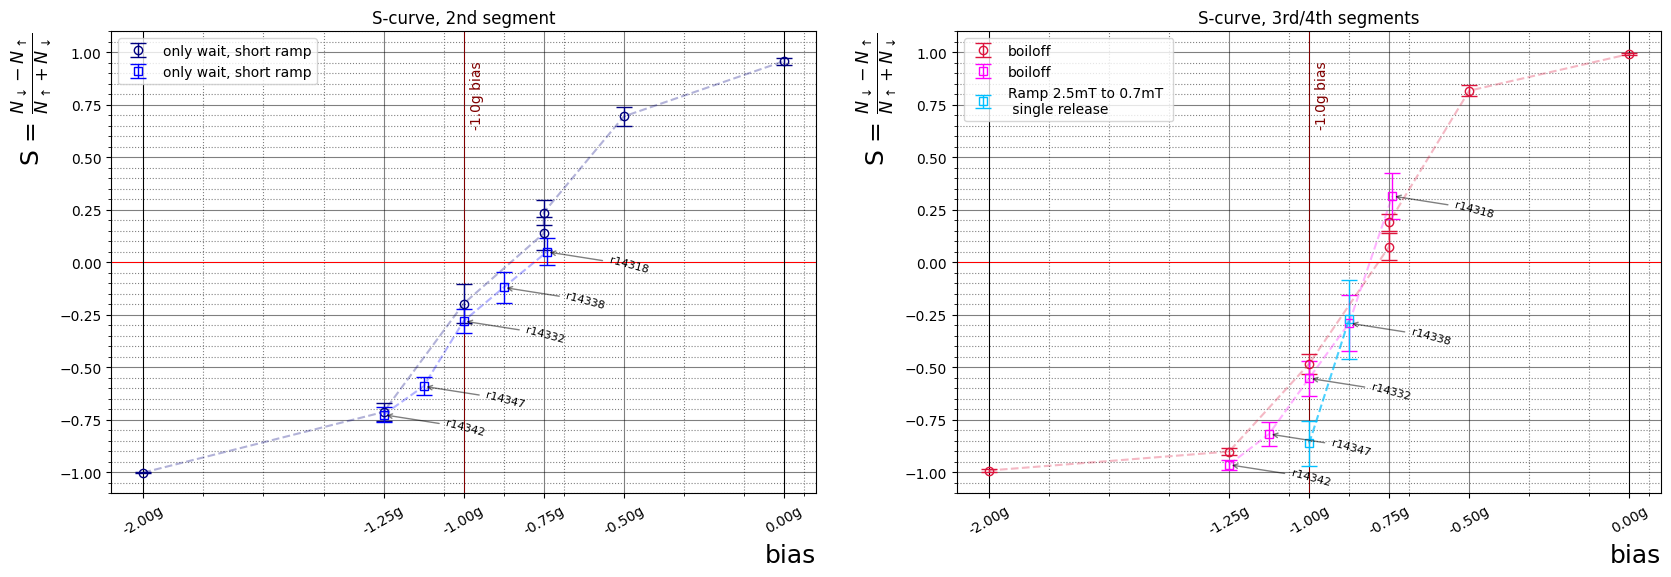

In [14]:
print("bias; S=Ndwn/(Ntot) ; dS")

labels = [ -2, -1.25, -1, -.75, -0.5, 0]

plt.figure(1, figsize = (20, 6))

#--------------------------------------------------------------
plt.subplot(1,2,1)
plt.title("S-curve, 2nd segment")
plotter_nicer()

# plot short ramps
mask = (type_ramp == "short")
plt.errorbar(bias[mask], 
             S_ramp2_onlywait[mask], 
             dS_ramp2_onlywait[mask], marker = "o", markersize = 6, markerfacecolor='none', color = "navy", capsize = 6, elinewidth=1, linestyle = "",  label = "only wait, short ramp")
plt.errorbar(bias[mask], S_ramp2_onlywait[mask], marker = "", color = "navy",  linestyle = "--", alpha = 0.3)
#labelfactory(bias, S_ramp2_onlywait, list_runs, labels)

# plot long ramps -> type_ramp
mask = (type_ramp == "long")
plt.errorbar(bias[mask], 
             S_ramp2_onlywait[mask], 
             dS_ramp2_onlywait[mask], marker = "s", markersize = 6, markerfacecolor='none', color = "blue", capsize = 6, elinewidth=1, linestyle = "",  label = "only wait, short ramp")
plt.errorbar(bias[mask], S_ramp2_onlywait[mask], marker = "", color = "blue",  linestyle = "--", alpha = 0.3)
labelfactory(bias[mask], S_ramp2_onlywait[mask], list_runs[mask], labels)
plt.legend()
plt.xticks(labels, [f"{item:.2f}g" for item in labels], rotation=30)

#--------------------------------------------------------------
plt.subplot(1,2,2)
plt.title("S-curve, 3rd/4th segments")
plotter_nicer()

# 3rd segment
# plot short ramps
mask = (type_ramp == "short")
plt.errorbar(bias[mask], 
             S_ramp3_onlywait[mask], 
             dS_ramp3_onlywait[mask], marker = "o", markerfacecolor='none', markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "boiloff")
plt.errorbar(bias[mask], S_ramp3_onlywait[mask], marker = "", color = "crimson", linestyle = "--", alpha = 0.3)
#labelfactory(bias[mask], S_ramp3_onlywait[mask], list_runs[mask], labels)


# plot long ramps -> type_ramp
mask = (type_ramp == "long")

plt.errorbar(bias[mask], 
             S_ramp3_onlywait[mask], 
             dS_ramp3_onlywait[mask], marker = "s", markerfacecolor='none', markersize = 6, color = "magenta", capsize = 6, elinewidth=1, linestyle = "", label = "boiloff")
plt.errorbar(bias[mask], S_ramp3_onlywait[mask], marker = "", color = "magenta", linestyle = "--", alpha = 0.3)
labelfactory(bias[mask], S_ramp3_onlywait[mask], list_runs[mask], labels)

mask = (type_ramp == "single")
plt.errorbar(bias[mask], 
             S_rampsingle_wait[mask], 
             dS_rampsingle_wait[mask], marker = "s", markersize = 6, markerfacecolor='none', color = "deepskyblue", capsize = 6, linestyle = '', elinewidth=1, label = "Ramp 2.5mT to 0.7mT \n single release")
plt.errorbar(bias[mask], S_rampsingle_wait[mask], marker = "", color = "deepskyblue", linestyle = "--", alpha = 0.7)

# segment 4 boil-off
# mask = (bias2 == -1) | (bias == -1.25)
# plt.errorbar(bias2[~mask], 
#             S_ramp4_onlywait[~mask], 
#             dS_ramp4_onlywait[~mask], marker = "s", markersize = 6, markerfacecolor='none', color = "darkorange", capsize = 6, linestyle = '', elinewidth=1, label = "seg.4 boiloff")

# plt.errorbar(bias2[mask], 
#              S_ramp4_onlywait[mask], 
#              dS_ramp4_onlywait[mask], marker = "x", markersize = 6, markerfacecolor='none', color = "black", capsize = 6, linestyle = '', elinewidth=1, label = "seg.4 only ramp [strange pattern]")

plt.legend()
plt.xticks(labels, [f"{item:.2f}g" for item in labels], rotation=30)

plt.savefig("figures/S_curve_onlywait.png", bbox_inches = 'tight')

In [15]:
# save the data in txt format
with open("data_onlyramp.txt", "w") as file:
    file.write("#run ; bias ; segment1 ; err. segment1 ; segment2 ; err. segment2 ; segment3 ; err. segment3 ; segment4 ; err. segment4 \n")
    for run, bias_, s1, s1_w, s2, s2_w, s3, s3_w, s4, s4_w in zip(list_runs,
                                                   bias,
                                                   S_ramp1,
                                                   dS_ramp1, 
                                                   S_ramp2,
                                                   dS_ramp2, 
                                                   S_ramp3,
                                                   dS_ramp3,
                                                   S_ramp4,
                                                   dS_ramp4):
        file.write(f"{run} \t {bias_:.2f} \t {s1:.2f} \t {s1_w:.2f} \t {s2:.2f} \t {s2_w:.2f} \t {s3:.2f} \t {s3_w:.2f} \t {s4:.2f} \t {s4_w:.2f}\n")

with open("data_onlywait.txt", "w") as file:
    file.write("#run ; bias ; segment1 ; err. segment1 ; segment2 ; err. segment2 ; segment3 ; err. segment3 ; segment4 ; err. segment4 \n")
    for run, bias_, s1, s1_w, s2, s2_w, s3, s3_w, s4, s4_w in zip(list_runs,
                                                   bias,
                                                   S_ramp1_onlywait,
                                                   dS_ramp1_onlywait, 
                                                   S_ramp2_onlywait,
                                                   dS_ramp2_onlywait, 
                                                   S_ramp3_onlywait,
                                                   dS_ramp3_onlywait,
                                                   S_ramp4_onlywait,
                                                   dS_ramp4_onlywait):
        file.write(f"{run} \t {bias_:.2f} \t {s1:.2f} \t {s1_w:.2f} \t {s2:.2f} \t {s2_w:.2f} \t {s3:.2f} \t {s3_w:.2f} \t {s4:.2f} \t {s4_w:.2f}\n")

# Comparison with 2022 Scurve

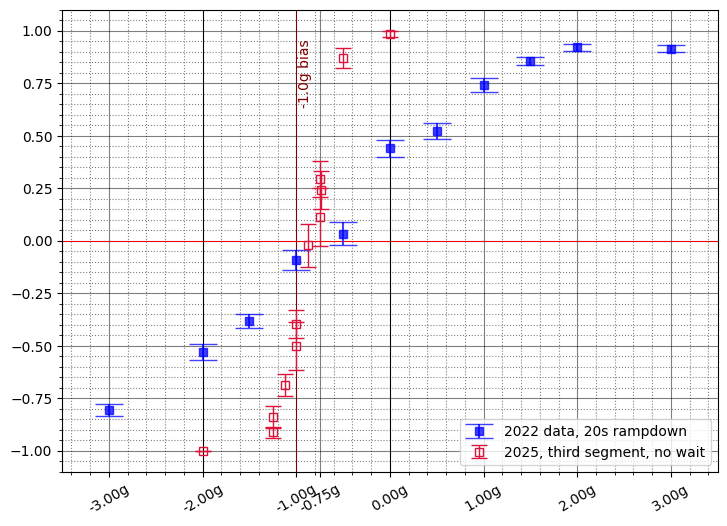

In [16]:
Asym      = np.load('../2022_scurve/Asym.npy')
#Loc_Magb  = np.load('../2022_scurve/Loc_Magb.npy')
dAsym     = np.load('../2022_scurve/dAsym.npy')
#dLoc_Magb = np.load('../2022_scurve/dLoc_Magb.npy')
mapping   = np.load('../2022_scurve/mapping.npy')
#Si  = np.load('../2022_scurve/Si.npy')
#Si0 = np.load('../2022_scurve/Si0.npy')

#scurve_20s = .5 * (1 - Asym)
scurve_20s = -Asym
#scurve_20s =  scurve_20s* (1 - D_efficiency_20s) /(1 + D_efficiency_20s  * (1 - 2* scurve_20s))
dscurve_20s = .5 * dAsym

plt.figure(2, figsize  = (1.41*6, 6))
plt.grid()
plt.minorticks_on()
plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
plt.ylim(-1.1,1.1)
plt.xlim(-3.5,3.5)
plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
#plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")
labels = [-3, -2, -1, -.75,  0, 1, 2, 3]
plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

#2022 Scurve
plt.errorbar(mapping/10, scurve_20s, dscurve_20s, marker = "s" , color = 'blue', label = '2022 data, 20s rampdown', markersize = 6, capsize = 10, linestyle = '', alpha = 0.75)

# 2025 third segment
plt.errorbar(bias, S_ramp3, dS_ramp3, marker = "s", markersize = 6, markerfacecolor='none', color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "2025, third segment, no wait")
#plt.errorbar(bias, S_ramp3_wait, dS_ramp3_wait, marker = "^", markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "including wait")
#plt.errorbar(bias, S_ramp3_onlywait, dS_ramp3_onlywait, marker = "*", markerfacecolor='none', markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "only wait")
#plt.errorbar(bias, S_boiloff, dS_boiloff, marker = "^", markerfacecolor='none', markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "boiloff")
plt.legend()
plt.savefig("comparison_s_curve.png")

In [17]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a

ZCUTS = Zcuts(-415,-671)

# Z distribution comparison

In [18]:
dataset_2023 = pd.read_csv("../../ag-easy/BKF/bkf_MAGB0.vertex.csv", delimiter = ',')
runToKey = {}
keyToRuns = {}
for l in open('../../ag-easy/BKF/bkf.maps').readlines():
    run, key  = l.split()
    runToKey.update({int(run):int(key)})
    try:
        runs = keyToRuns[int(key)]
    except:
        runs = []        
    runs.append(int(run))
    keyToRuns.update({int(key):runs})

for key, item in runToKey.items():
    print(f"key/run {key}; value {item}")
#print(runToKey)

key/run 9677; value 101
key/run 9691; value 101
key/run 9671; value 101
key/run 9663; value 101
key/run 9696; value 101
key/run 9658; value 101
key/run 9382; value 100
key/run 9392; value 100
key/run 9408; value 100
key/run 9422; value 100
key/run 9412; value 100
key/run 9384; value 100
key/run 9634; value 30
key/run 9614; value 30
key/run 9622; value 30
key/run 9672; value 30
key/run 9586; value 30
key/run 9618; value 30
key/run 9595; value 30
key/run 9647; value 20
key/run 9668; value 20
key/run 9502; value 20
key/run 9461; value 20
key/run 9566; value 20
key/run 9561; value 20
key/run 9571; value 20
key/run 9513; value 10
key/run 9664; value 10
key/run 9569; value 10
key/run 9558; value 10
key/run 9503; value 10
key/run 9464; value 10
key/run 9471; value 10
key/run 9702; value 15
key/run 9713; value 15
key/run 9724; value 15
key/run 9728; value 15
key/run 9718; value 15
key/run 9732; value 15
key/run 9644; value 5
key/run 9630; value 5
key/run 9687; value 5
key/run 9616; value 5
key

In [19]:
from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

#----------------------
dataset_2025_1 = ReadTheCsv("../v1/ag14100/ag14100.vertex.csv","-1", zmin, zmax, CutsType)
dataset_2025_2 = ReadTheCsv("../v1/ag14106/ag14106.vertex.csv","-1", zmin, zmax, CutsType)

dataset_2025 = pd.concat([dataset_2025_1, dataset_2025_2], axis=0)

ag14100/ag14100.vertex.csv
   [26640.301-26740.304]= 100.003s |          "WaitForQuasitrapped"[0]    |   10556      507      530      349     5310     3878    12216     7721    20590        38 

ag14100/ag14100.vertex.csv
   [27249.259-27849.266]= 600.008s |          "WaitForQuasitrapped"[1]    |   63267     3287     3233     2072    32031    23689    73469    45788   124065       378 

ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

ag14106/ag14106.vertex.cs

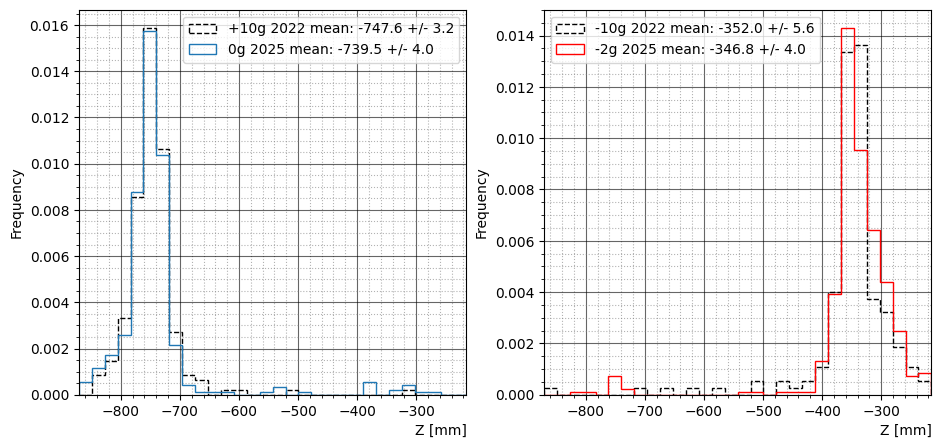

In [20]:
plt.figure(figsize = (11, 5))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

mask = (dataset_2023["CutsType7"] == 1) & ((dataset_2023["Run Number"].map(runToKey) == 101)) & (dataset_2023["Z"] > ZCUTS.zmin) & ( dataset_2023["Z"] < ZCUTS.zmax)

dataset_2023["Z"][mask].plot(kind = 'hist',
                             bins = 30,
                             range = [zmin, zmax],
                             histtype = 'step',
                             linestyle = "--",
                             color = 'black',
                             label = f"+10g 2022 mean: { dataset_2023['Z'][mask].mean():.4} +/- {dataset_2023['Z'][mask].std()/np.sqrt(dataset_2023['Z'][mask].size):.2}",
                             density = True,
                             ax = ax1)

mask = (dataset_2023["CutsType7"] == 1) & ((dataset_2023["Run Number"].map(runToKey) == -101)) & (dataset_2023["Z"] > ZCUTS.zmin) & ( dataset_2023["Z"] < ZCUTS.zmax)

dataset_2023["Z"][mask].plot(kind = 'hist',
                             bins = 30,
                             range = [zmin, zmax],
                             histtype = 'step',
                             linestyle = "--",
                             color = 'black',
                             label = f"-10g 2022 mean: {dataset_2023['Z'][mask].mean():.4} +/- {dataset_2023['Z'][mask].std()/np.sqrt(dataset_2023['Z'][mask].size):.2}",
                             density = True,
                             ax = ax2)

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill("ag14100/ag14100.vertex.csv", "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill("ag14100/ag14100.vertex.csv", "\"WaitForQuasitrapped\"[1]")
# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill("ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill("ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill("ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[2]")

mask      = (dataset_2025[CutsType] == 1) & (dataset_2025["Run Number"] == 14100) & (dataset_2025["Z"] > ZCUTS.zmin) & ( dataset_2025["Z"] < ZCUTS.zmax)
mask_time = ((dataset_2025["run time"] > start_mbmf_rampdown0[0]) & (dataset_2025["run time"] < start_mbmf_rampdown2[0]))

dataset_2025["Z"][mask & mask_time].plot(kind = 'hist',
                                         bins = 30,
                                         range = [zmin, zmax],
                                         histtype = 'step',
                                         label = f"0g 2025 mean: {dataset_2025['Z'][mask & mask_time].mean():.4} +/- {dataset_2025['Z'][mask & mask_time].std() / np.sqrt(dataset_2025['Z'][mask & mask_time].size):.2}",
                                         density = True,
                                         ax = ax1)

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill("ag14106/ag14106.vertex.csv", "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill("ag14106/ag14106.vertex.csv", "\"WaitForQuasitrapped\"[1]")

# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill("ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill("ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill("ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[2]")

mask      = (dataset_2025[CutsType] == 1) & (dataset_2025["Run Number"] == 14106) & (dataset_2025["Z"] > ZCUTS.zmin) & ( dataset_2025["Z"] < ZCUTS.zmax)
mask_time = ((dataset_2025["run time"] > start_mbmf_rampdown0[0]) & (dataset_2025["run time"] < start_mbmf_rampdown2[0]))

dataset_2025["Z"][mask & mask_time].plot(kind = 'hist',
                                         bins = 30,
                                         range = [zmin, zmax],
                                         histtype = 'step',
                                         label = f"-2g 2025 mean: {dataset_2025['Z'][mask & mask_time].mean():.4} +/- {dataset_2025['Z'][mask & mask_time].std() / np.sqrt(dataset_2025['Z'][mask & mask_time].size):.2}",
                                         color = "red",
                                         density = True,
                                         ax = ax2)

ax2.minorticks_on()
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel("Z [mm]",loc = "right")
ax2.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax2.grid(which='minor', linestyle=':', color='gray', alpha = 0.6) #Griglia minore: linea tratteggiata grigia
ax2.legend()

ax1.minorticks_on()
ax1.set_xlim(zmin, zmax)
ax1.set_xlabel("Z [mm]",loc = "right")
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray', alpha = 0.6) #Griglia minore: linea tratteggiata grigia
ax1.legend()
plt.savefig("Zpdf_comparison.png", bbox_inches = 'tight')